## **Part 1: Analyzing Best-Seller Trends Across Product Categories**

**Objective:** Understand the relationship between product categories and their best-seller status.

**1. Crosstab Analysis:**

- Create a crosstab between the product category and the isBestSeller status.

- Are there categories where being a best-seller is more prevalent?

Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

df = pd.read_csv('amz_uk_price_prediction_dataset.csv')
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [2]:
crosstab = pd.crosstab(df['category'], df['isBestSeller'])
proportion =  pd.crosstab(df['category'], df['isBestSeller'], normalize='index')
proportion

isBestSeller,False,True
category,,
3D Printers,0.995968,0.004032
3D Printing & Scanning,0.999508,0.000492
Abrasive & Finishing Products,0.980000,0.020000
Action Cameras,0.999411,0.000589
Adapters,0.988189,0.011811
...,...,...
Wind Instruments,0.972000,0.028000
Window Treatments,0.979079,0.020921
Women,0.988015,0.011985


In [3]:
proportion[True].sort_values(ascending=False)

category
Grocery                             0.058135
Smart Home Security & Lighting      0.057692
Health & Personal Care              0.057686
Mobile Phone Accessories            0.042471
Power & Hand Tools                  0.035339
                                      ...   
CD, Disc & Tape Players             0.000000
General Music-Making Accessories    0.000000
Snowboard Boots                     0.000000
Boxes & Organisers                  0.000000
eBook Readers & Accessories         0.000000
Name: True, Length: 296, dtype: float64

Answer: Yes, some categories have a higher prevalence of best-sellers, like Grocery, Smart Home Securitu & Lighting and Health & Personal Care.

**2. Statistical Tests:**

- Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
- Compute Cramér's V to understand the strength of association between best-seller status and category.

In [4]:
from scipy.stats import chi2_contingency

chi2_statistic, chi2_p_value, _, expected_freq = chi2_contingency(crosstab)

chi2_statistic, chi2_p_value, expected_freq

(np.float64(36540.20270061387),
 np.float64(0.0),
 array([[2.47190130e+02, 8.09870149e-01],
        [4.05371878e+03, 1.32812173e+01],
        [2.49183599e+02, 8.16401360e-01],
        [1.69145827e+03, 5.54173243e+00],
        [2.53170536e+02, 8.29463782e-01],
        [8.50214439e+03, 2.78556144e+01],
        [1.06650580e+02, 3.49419782e-01],
        [2.57157474e+02, 8.42526204e-01],
        [9.51781673e+03, 3.11832664e+01],
        [1.50008526e+04, 4.91473619e+01],
        [9.32544700e+03, 3.05530045e+01],
        [2.38219520e+02, 7.80479700e-01],
        [3.22941944e+03, 1.05805616e+01],
        [9.44704859e+03, 3.09514084e+01],
        [6.68808779e+03, 2.19122125e+01],
        [5.26275760e+02, 1.72423967e+00],
        [1.90296531e+04, 6.23469391e+01],
        [2.77191835e+03, 9.08164873e+00],
        [2.53170536e+02, 8.29463782e-01],
        [4.04674164e+02, 1.32583581e+00],
        [1.92489346e+04, 6.30653723e+01],
        [3.10482764e+03, 1.01723609e+01],
        [2.04330551e+02, 6

The Chi-square test returned a p-value of 0.0. This indicates that best-seller status is significantly associated with product category and is not independent of it.

In [6]:
from scipy.stats.contingency import association

association(crosstab, method="cramer")

0.1222829439760564

This indicates a weak association between product category and best-seller status.

**3. Visualizations:**

- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.


<Axes: xlabel='category'>

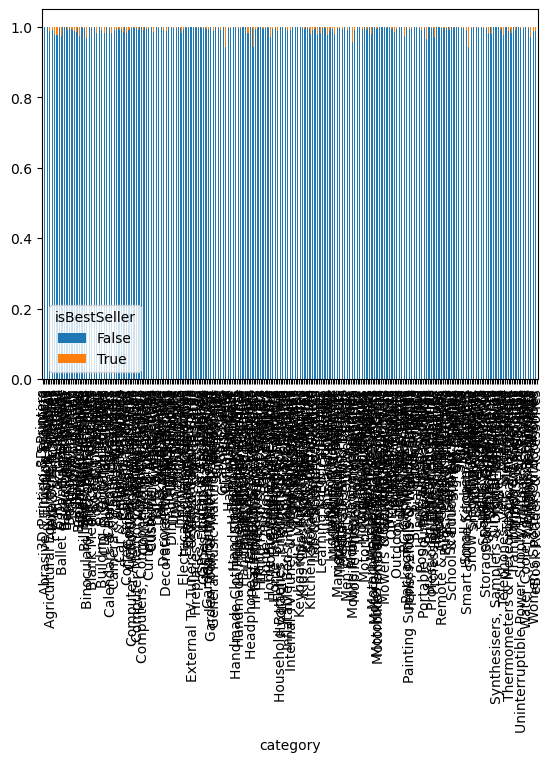

In [11]:
import matplotlib.pyplot as plt

proportion.plot(kind="bar", stacked=True)

Because there are so many categories, let's visualize the top 10.

<Axes: xlabel='category'>

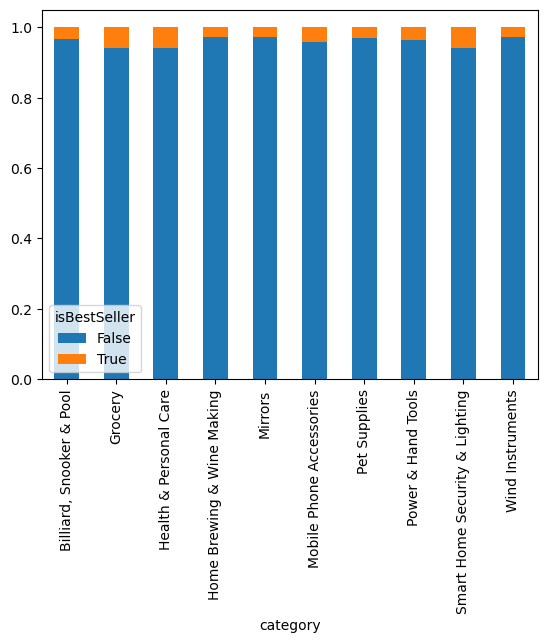

In [16]:
top10_prop = proportion[True].sort_values(ascending=False).head(10)

top10_categories = top10_prop.index
df_top = df[df['category'].isin(top10_categories)]

proportion = pd.crosstab(df_top['category'], df_top['isBestSeller'], normalize='index')

proportion.plot(kind='bar', stacked=True)


## **Part 2: Exploring Product Prices and Ratings Across Categories and Brands**

**Objective:** Investigate how different product categories influence product prices.

**0. Preliminary Step: Remove outliers in product prices.**

For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.

Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.

In [19]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[
    (df['price'] >= lower_bound) & 
    (df['price'] <= upper_bound)
]

df_no_outliers

print("Original size:", len(df))
print("After removing outliers:", len(df_no_outliers))

Original size: 2443651
After removing outliers: 2115963


**1. Violin Plots:**

- Use a violin plot to visualize the distribution of price across different product categories. Filter out the top 20 categories based on count for better visualization.
- Which product category tends to have the highest median price? Don't filter here by top categories.

C:\Users\franc\AppData\Local\Temp\ipykernel_10504\2320566914.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_top20, x='category', y='price', palette="coolwarm", legend=False)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'Handmade Home & Kitchen Products'),
  Text(1, 0, 'Sports & Outdoors'),
  Text(2, 0, 'Handmade Gifts'),
  Text(3, 0, 'Fragrances'),
  Text(4, 0, 'Skin Care'),
  Text(5, 0, 'Birthday Gifts'),
  Text(6, 0, 'Handmade Kitchen & Dining'),
  Text(7, 0, 'Bath & Body'),
  Text(8, 0, 'Manicure & Pedicure Products'),
  Text(9, 0, 'Beauty'),
  Text(10, 0, 'Handmade Artwork'),
  Text(11, 0, 'Make-up'),
  Text(12, 0, 'Baby'),
  Text(13, 0, 'Handmade Clothing, Shoes & Accessories'),
  Text(14, 0, 'Handmade Home Décor'),
  Text(15, 0, 'Men'),
  Text(16, 0, 'Luggage and travel gear'),
  Text(17, 0, 'Handmade Jewellery'),
  Text(18, 0, 'Women'),
  Text(19, 0, 'Hair Care')])

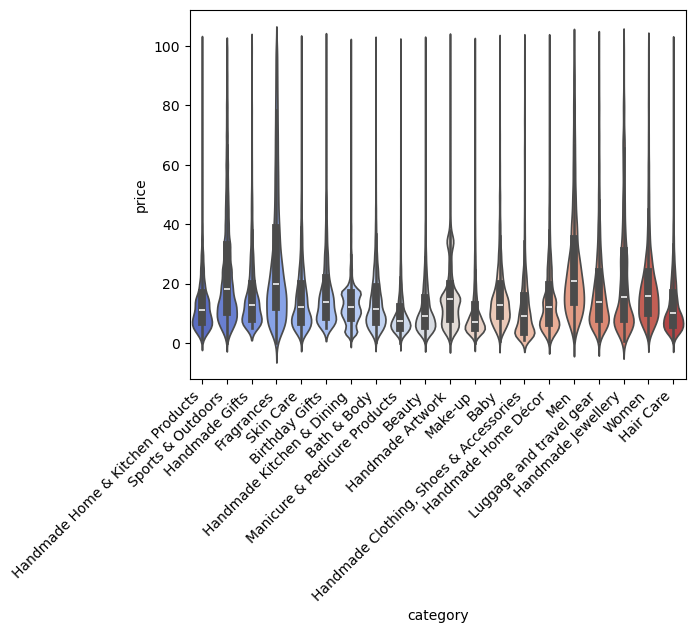

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

top_20 = df_no_outliers['category'].value_counts().head(20).index
df_top20 = df_no_outliers[df_no_outliers['category'].isin(top_20)]
sns.violinplot(data=df_top20, x='category', y='price', palette="coolwarm", legend=False)
plt.xticks(rotation=45, ha='right')

In [35]:
median_prices = df_no_outliers.groupby('category')['price'].median()

highest_category = median_prices.sort_values(ascending=False).head(1)

print(highest_category)

category
Desktop PCs    74.0
Name: price, dtype: float64


**2. Bar Charts:**

- Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
- Which product category commands the highest average price? Don't filter here by top categories.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Sports & Outdoors'),
  Text(1, 0, 'Handmade Gifts'),
  Text(2, 0, 'Skin Care'),
  Text(3, 0, 'Birthday Gifts'),
  Text(4, 0, 'Bath & Body'),
  Text(5, 0, 'Manicure & Pedicure Products'),
  Text(6, 0, 'Beauty'),
  Text(7, 0, 'Make-up'),
  Text(8, 0, 'Handmade Clothing, Shoes & Accessories'),
  Text(9, 0, 'Hair Care')])

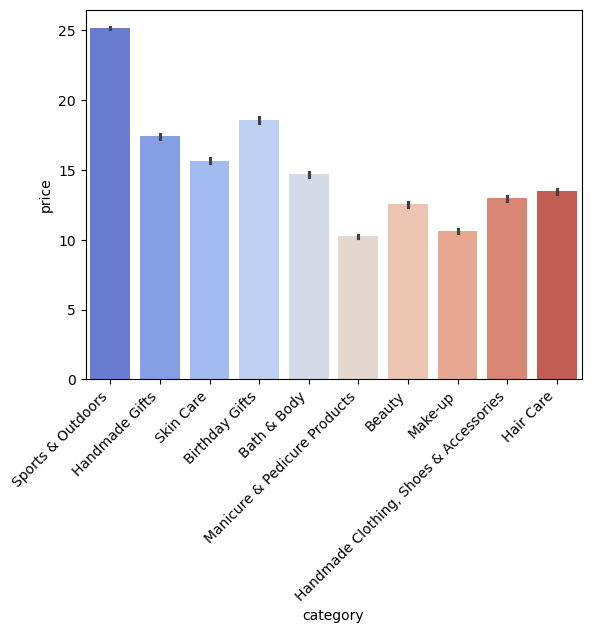

In [37]:
top_10 = df_no_outliers['category'].value_counts().head(10).index
df_top10 = df_no_outliers[df_no_outliers['category'].isin(top_10)]

sns.barplot(data=df_top10, x='category', y='price', palette="coolwarm", hue='category', legend=False)
plt.xticks(rotation=45, ha='right')

In [38]:
average_price = df_no_outliers.groupby('category')['price'].mean()

highest_average_price = average_price.sort_values(ascending=False).head(1)

print(highest_average_price)

category
Motherboards    68.772432
Name: price, dtype: float64


**3. Box Plots:**

- Visualize the distribution of product ratings based on their category using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
- Which category tends to receive the highest median rating from customers? Don't filter here by top categories.


C:\Users\franc\AppData\Local\Temp\ipykernel_10504\2050971342.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, x='category', y='stars', palette="coolwarm")


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Sports & Outdoors'),
  Text(1, 0, 'Handmade Gifts'),
  Text(2, 0, 'Skin Care'),
  Text(3, 0, 'Birthday Gifts'),
  Text(4, 0, 'Bath & Body'),
  Text(5, 0, 'Manicure & Pedicure Products'),
  Text(6, 0, 'Beauty'),
  Text(7, 0, 'Make-up'),
  Text(8, 0, 'Handmade Clothing, Shoes & Accessories'),
  Text(9, 0, 'Hair Care')])

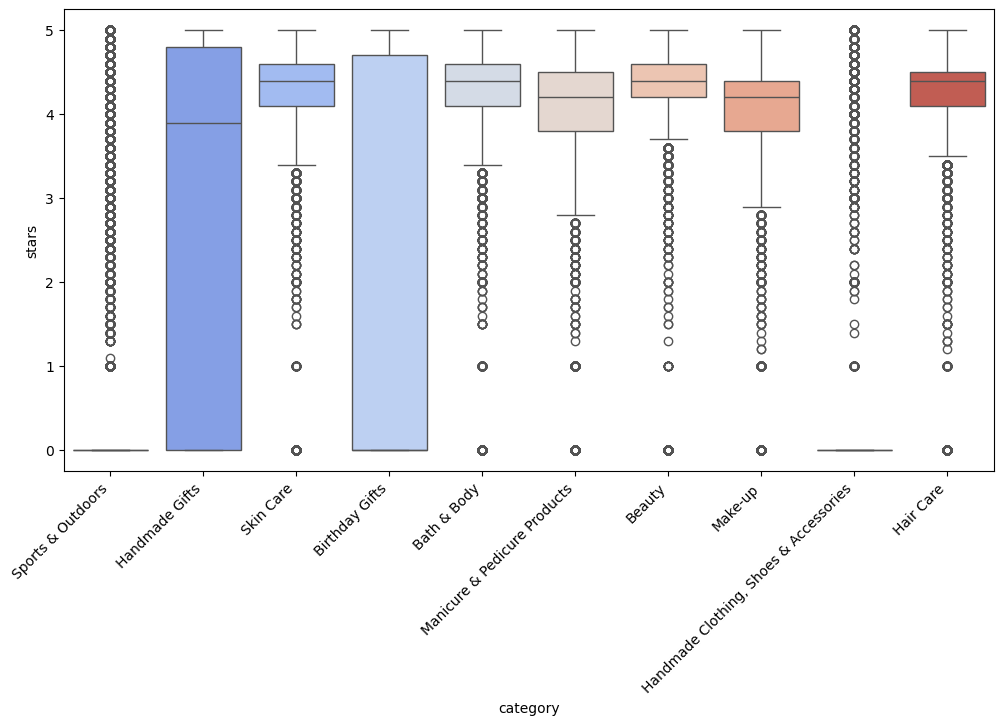

In [45]:
top_10 = df_no_outliers['category'].value_counts().head(10).index
df_top10 = df_no_outliers[df_no_outliers['category'].isin(top_10)]

plt.figure(figsize=(12,6))

sns.boxplot(data=df_top10, x='category', y='stars', palette="coolwarm")
plt.xticks(rotation=45, ha='right')

In [46]:
median_rating = df_no_outliers.groupby('category')['stars'].median()

highest_median_rating = median_rating.sort_values(ascending=False).head(1)

print(highest_median_rating)

category
Computer Memory    4.7
Name: stars, dtype: float64


## **Part 3: Investigating the Interplay Between Product Prices and Ratings**

**Objective:** Analyze how product ratings (stars) correlate with product prices.

**1. Correlation Coefficients:**

- Calculate the correlation coefficient between price and stars.
- Is there a significant correlation between product price and its rating?


In [47]:
correlation = df['stars'].corr(df['price'])
correlation

np.float64(-0.12490673262148609)

There is a weak negative relatioship between price and ratings, meaning that as price increases, ratings tend do slightly decrease.

**2. Visualizations:**

- Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
- Use a correlation heatmap to visualize correlations between all numerical variables.
- Examine if product prices typically follow a normal distribution using a QQ plot.

<Axes: xlabel='stars', ylabel='price'>

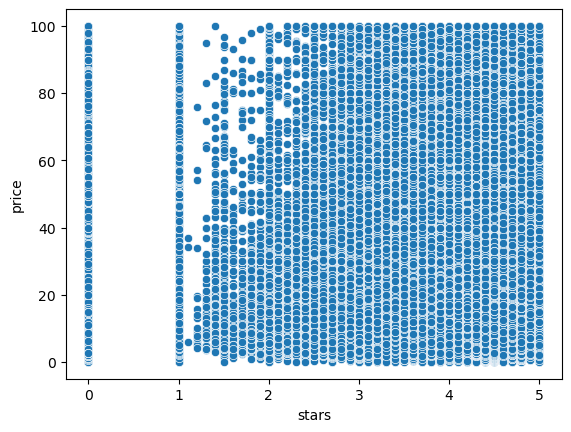

In [48]:
sns.scatterplot(data=df_no_outliers, x='stars', y='price')

The scatter plot shows no clear relationship between price and ratings. Prices vary widely at all rating levels, indicating that product price does not strongly influence ratings.

In [49]:
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2115963 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 147.3+ MB


In [50]:
df_numerical = df_no_outliers.select_dtypes("number")

In [51]:
df_numerical.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2115963 entries, 0 to 2443650
Data columns (total 5 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   stars              float64
 2   reviews            int64  
 3   price              float64
 4   boughtInLastMonth  int64  
dtypes: float64(2), int64(3)
memory usage: 96.9 MB


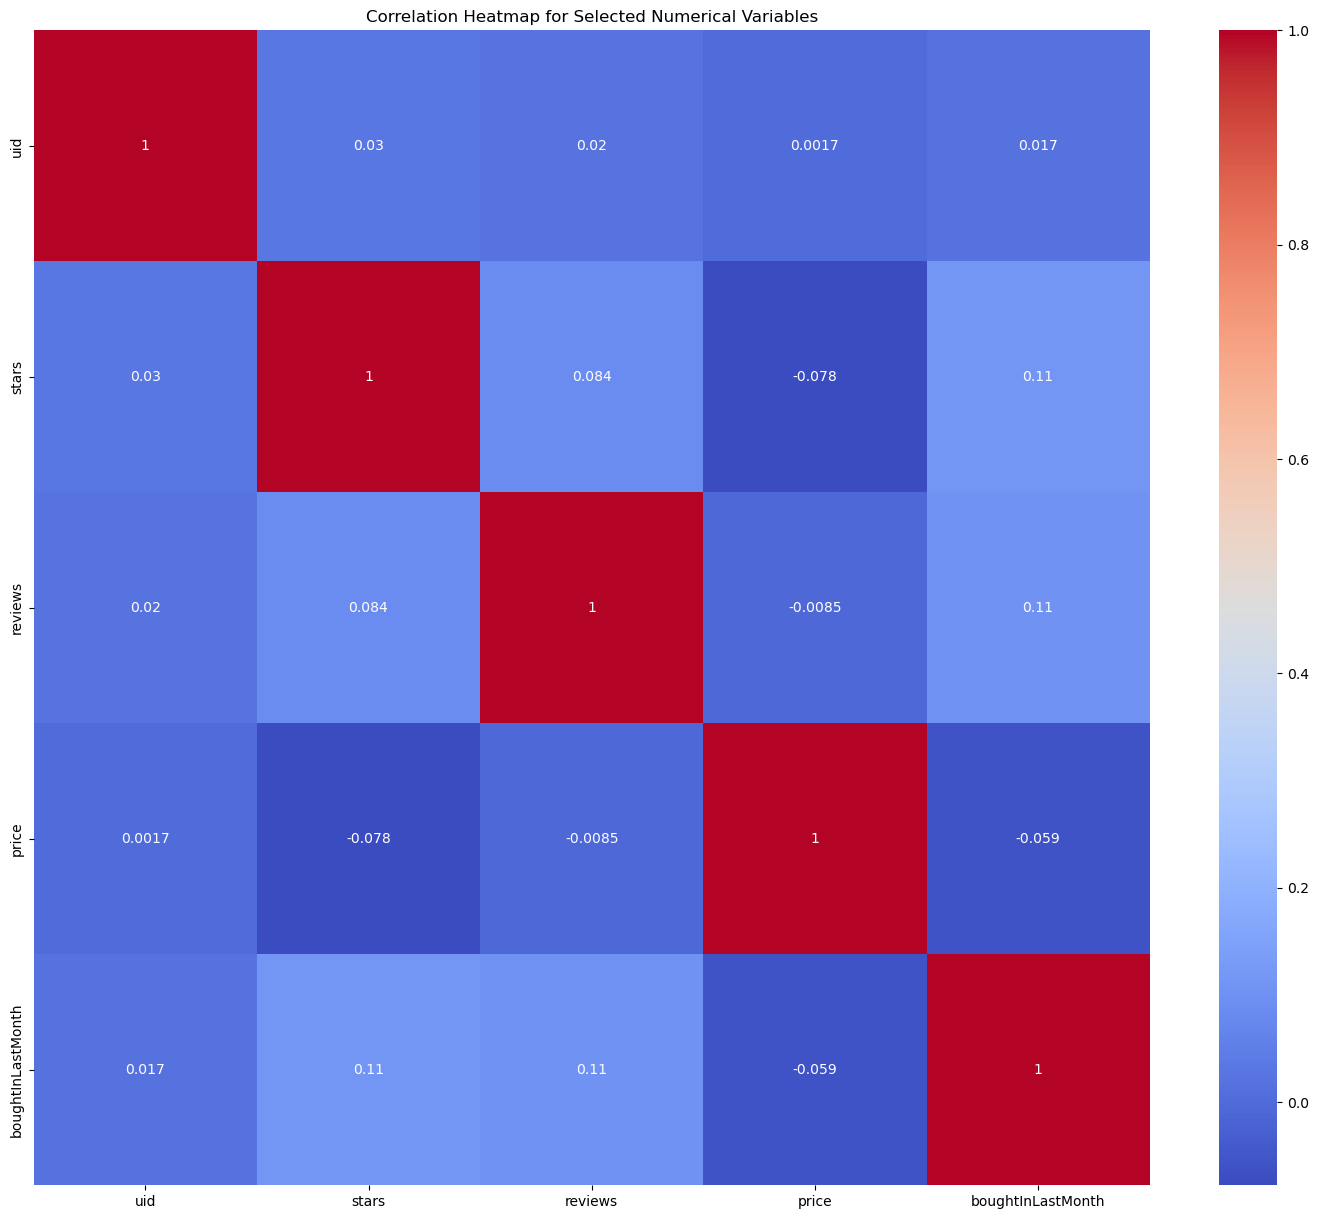

In [52]:
correlation_matrix = df_numerical.corr()

plt.figure(figsize=(18, 15))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap for Selected Numerical Variables")
plt.show()

The correlation heatmap shows that most numerical variables have very weak correlations with each other, with values close to zero. This indicates that there are no strong linear relationships between the variables in the dataset.

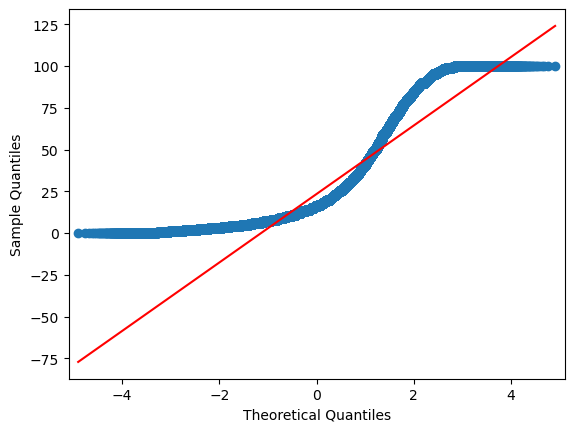

In [53]:
import statsmodels.api as sm

sm.qqplot(df_no_outliers['price'], line='s');

The QQ plot shows a clear deviation from the reference line, indicating that product prices do not follow a normal distribution.